# Atividade de programação

A atividade de programação é sobre classificação de pedestre utilizando uma rede neural.

1. **Parte 1**: Crie uma rede neural para classificação de pedestre

  - O conjunto de treinamento e teste estão disponíveis nos arquivos **dados_pessoas_treinamento.csv** e **dados_pessoas_teste.csv**.

  - Para cada amostra do conjunto de treinamento temos 6195 características extraídas de uma região da imagem e um rotulo pedestre (1) ou não-pedestre (0).
  - Seu classificador deve obter um percentual acima de 95% nos dados de treinamento e teste


2. **Parte 2**: Faça uma validação do seu modelo
  - Além disso, seu classificador deve obter um percentual de 100% em um conjunto de dados não tratados, ou seja, imagens. Para isso: (1) leia imagem; (2) aplique o algoritmo do LBP para obter um vetor de entrada $x$ para o seu classificador; (3) normalize esse vetor de entrada; (4) faça a predição no vetor de entrada $x$.

# **Parte 1**: Crie uma rede neural para classificação de pedestre

In [ ]:
#conjunto de treinamento
!wget https://www.dropbox.com/s/93hngeb0hvh5kte/dados_pessoas_treinamento.csv
!wget https://www.dropbox.com/s/q2rtk6qwftx45nr/dados_pessoas_teste.csv



1. Criando os conjunto de treinamento e teste



In [ ]:
import pandas as pd
import numpy as np

dados_treinamento = pd.read_csv("dados_pessoas_treinamento.csv", header=None)
dados_teste = pd.read_csv("dados_pessoas_teste.csv", header=None)

XTrain = dados_treinamento.values[:,0:-1]
YTrain = dados_treinamento.values[:,-1]

XTest = dados_teste.values[:, 0:-1]
YTest = dados_teste.values[:, -1]

print("Shapes")
print("XTrain:", XTrain.shape)
print("YTrain:", YTrain.shape)
print("XTest:", XTest.shape)
print("YTest:", YTest.shape)

Shapes
XTrain: (2703, 6195)
YTrain: (2703,)
XTest: (2703, 6195)
YTest: (2703,)


  2. Normalização dos dados

In [ ]:
from sklearn.preprocessing import StandardScaler

zscore = StandardScaler()
zscore.fit(XTrain)

XTrain = zscore.transform(XTrain)
XTest = zscore.transform(XTest)

  3. Criação o modelo  

In [ ]:
import tensorflow as tf
import tensorflow.keras as keras

model = keras.models.Sequential()  # Cria uma rede neural sequencial - feed foward

# camada de entrada
model.add( keras.layers.InputLayer(input_shape=XTrain.shape[1] ) )

# primeira hidden layer
model.add( keras.layers.Dense(100, activation='LeakyReLU') )
#model.add( keras.layers.Dropout(0.2) )

# segunda hidden layer
model.add( keras.layers.Dense(50, activation='LeakyReLU') )
#model.add( keras.layers.Dropout(0.2) )

# camada de saida
model.add( keras.layers.Dense(1, activation= 'sigmoid') ) # output layer com ativação sigmoid




model.compile(loss=keras.losses.binary_crossentropy,
             #optimizer=keras.optimizers.SGD(learning_rate=0.001),
              optimizer=keras.optimizers.Adam(),
             metrics=['accuracy'])

model.summary()

Model: "sequential_21"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_60 (Dense)             (None, 100)               619600    
_________________________________________________________________
dense_61 (Dense)             (None, 50)                5050      
_________________________________________________________________
dense_62 (Dense)             (None, 1)                 51        
Total params: 624,701
Trainable params: 624,701
Non-trainable params: 0
_________________________________________________________________


  3. Treinamento do modelo

In [ ]:
batch_size = 32  # X_train 535 / 32 = 16.71 (então são 17 batches de 32)
epochs = 50

history  = model.fit(XTrain, YTrain,
                     batch_size=batch_size,
                     epochs=epochs,
                     verbose=1,
                     validation_data=(XTest, YTest))

  4. Graficos sobre o desempenho do modelo

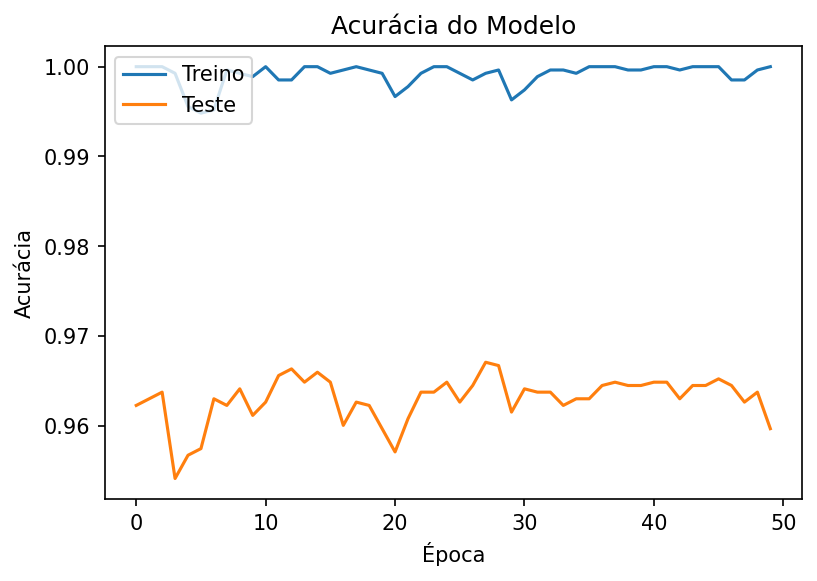

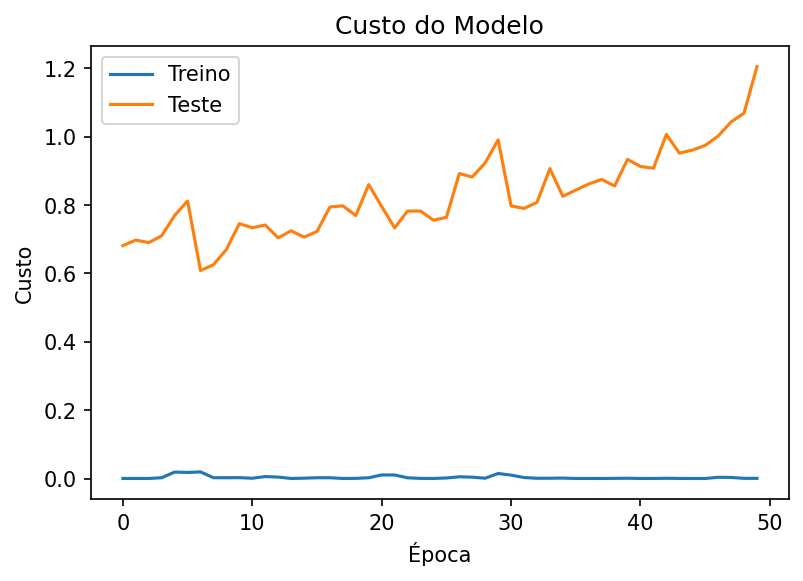

In [ ]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.dpi'] = 150

# Plot acurácia de treino e validação
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Acurácia do Modelo')
plt.ylabel('Acurácia')
plt.xlabel('Época')
plt.legend(['Treino', 'Teste'], loc='upper left')
plt.show()

# Plot custo de treino e validação
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Custo do Modelo')
plt.ylabel('Custo')
plt.xlabel('Época')
plt.legend(['Treino', 'Teste'], loc='upper left')
plt.show()

# **Parte 2**: Faça uma validação do seu modelo

# Extração de características da imagem
 - Método Local Binary Pattern (LBP)

In [ ]:
from skimage.util import view_as_windows #janela deslizante
from skimage.feature import local_binary_pattern #método do LBP
import numpy as np

#Local binary pattern (LBP)
def extracao_de_caracteristicas_LBP(img):

    # Parametros do LBP
    lbp_win_shape = (16, 16) #tamanho da bloco
    lbp_win_step = lbp_win_shape[0]/2 #passo da janela deslizante
    lbp_radius = 1
    lbp_n_points = 8 * lbp_radius
    lbp_METHOD = 'uniform'
    lbp_n_bins = 59

    lbp = local_binary_pattern(img, lbp_n_points, lbp_radius, lbp_METHOD)

    lbp_windows = view_as_windows(lbp, window_shape=lbp_win_shape, step=int(lbp_win_step))
    features = []
    count = 0
    for windows_list in lbp_windows:
        for window in windows_list:
            lbp_hist, bin_edges = np.histogram(window, bins=lbp_n_bins)
            lbp_hist_norm = sum(abs(lbp_hist))
            lbp_hist_l1sqrtnorm = np.sqrt(lbp_hist/float(lbp_hist_norm))

            features.append(lbp_hist)
            count += 1
    features_flatten = [item for sublist in features for item in sublist]
    return features_flatten


# Conjunto de validação

In [ ]:
#dados para criação do conjunto de treinamento - isso é só uma pequena parte dos dados
!wget https://www.dropbox.com/sh/v8ljm8r6iihv26s/AAAPwM4-ogZVk9AIxzd1CiRHa
!mv AAAPwM4-ogZVk9AIxzd1CiRHa dataset.zip
!unzip dataset.zip

# Predição do classificador
 - Estamos supondo que o classificador foi treinado utilizando os dados do conjunto de treinamento.

In [ ]:
#predicao
def predicao_classificador(X):
  predicao = model.predict(X)
  return predicao

#normalizacao
def normalizar(X):
  XNorm = zscore.transform(X)
  return XNorm



In [ ]:
import os
import random
import cv2 #biblioteca opencv da Intel
from google.colab.patches import cv2_imshow

conj_validacao = []
for arquivo in os.scandir('Background'):
  amostra =  (cv2.imread(arquivo.path, cv2.IMREAD_GRAYSCALE), 'Não é pedestre')
  conj_validacao.append(amostra)

for arquivo in os.scandir('Pedestrians'):
  amostra =  (cv2.imread(arquivo.path, cv2.IMREAD_GRAYSCALE), 'Pedestre')
  conj_validacao.append(amostra)

random.shuffle(conj_validacao)

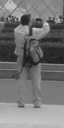

Classificado como: pedestre
Saída esperada: Pedestre 



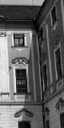

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



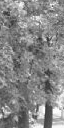

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



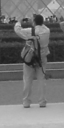

Classificado como: pedestre
Saída esperada: Pedestre 



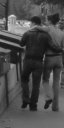

Classificado como: pedestre
Saída esperada: Pedestre 



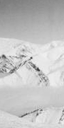

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



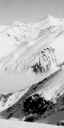

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



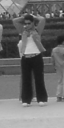

Classificado como: pedestre
Saída esperada: Pedestre 



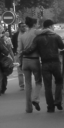

Classificado como: pedestre
Saída esperada: Pedestre 



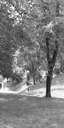

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



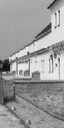

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



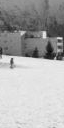

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



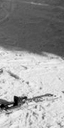

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



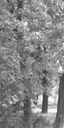

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



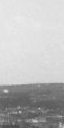

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



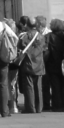

Classificado como: pedestre
Saída esperada: Pedestre 



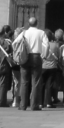

Classificado como: pedestre
Saída esperada: Pedestre 



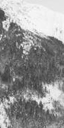

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



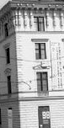

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



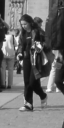

Classificado como: pedestre
Saída esperada: Pedestre 



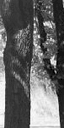

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



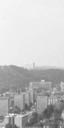

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



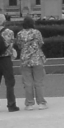

Classificado como: pedestre
Saída esperada: Pedestre 



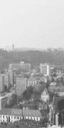

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



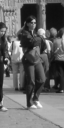

Classificado como: pedestre
Saída esperada: Pedestre 



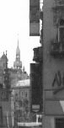

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



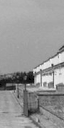

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



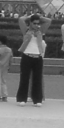

Classificado como: pedestre
Saída esperada: Pedestre 



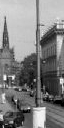

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



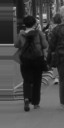

Classificado como: pedestre
Saída esperada: Pedestre 



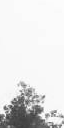

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



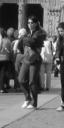

Classificado como: pedestre
Saída esperada: Pedestre 



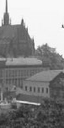

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



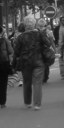

Classificado como: pedestre
Saída esperada: Pedestre 



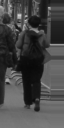

Classificado como: pedestre
Saída esperada: Pedestre 



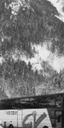

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



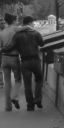

Classificado como: pedestre
Saída esperada: Pedestre 



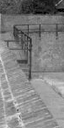

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



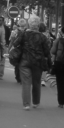

Classificado como: pedestre
Saída esperada: Pedestre 



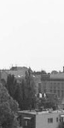

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



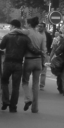

Classificado como: pedestre
Saída esperada: Pedestre 



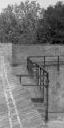

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



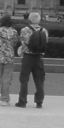

Classificado como: pedestre
Saída esperada: Pedestre 



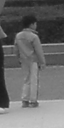

Classificado como: pedestre
Saída esperada: Pedestre 



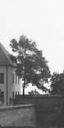

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



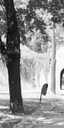

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



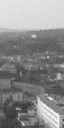

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



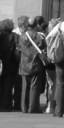

Classificado como: pedestre
Saída esperada: Pedestre 



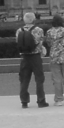

Classificado como: pedestre
Saída esperada: Pedestre 



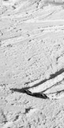

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



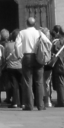

Classificado como: pedestre
Saída esperada: Pedestre 



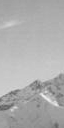

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



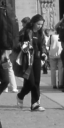

Classificado como: pedestre
Saída esperada: Pedestre 



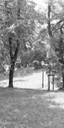

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



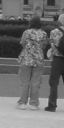

Classificado como: Não é pedestre
Saída esperada: Pedestre 



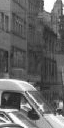

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



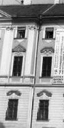

Classificado como: Não é pedestre
Saída esperada: Não é pedestre 



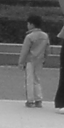

Classificado como: pedestre
Saída esperada: Pedestre 

Taxa de acerto: 98.27586206896551%
Taxa de erro: 1.7241379310344827%


In [ ]:
quant_acertos = 0
quant_erros = 0
for (imagem, saida_esperada) in conj_validacao: #extraindo os dados da pasta Background
  #abrindo a imagem

  X = np.array([ extracao_de_caracteristicas_LBP(imagem) ])
  X = normalizar(X)
  y = predicao_classificador(X)
  cv2_imshow(imagem)
  if(y == 1):
    print("Classificado como: pedestre")
    if(saida_esperada == "Pedestre"):
      quant_acertos += 1
    else:
      quant_erros += 1
  else:
    print("Classificado como: Não é pedestre")
    if(saida_esperada == "Não é pedestre"):
      quant_acertos += 1
    else:
      quant_erros += 1

  print("Saída esperada:", saida_esperada, "\n")

print("Taxa de acerto: "+ (format(quant_acertos / (quant_acertos + quant_erros)*100))+ "%" )
print("Taxa de erro: "+ (format(quant_erros / (quant_acertos + quant_erros)*100))+"%" )